In [101]:
import numpy as np
import matplotlib.pyplot as plt
import jax.random as jrd
import jax.numpy as jnp
import optax
from evoscape.landscapes import Landscape
from evoscape.modules import Node
from evoscape.landscape_visuals import *
from evoscape.jax import pytree_to_landscape
from evoscape.morphogen_regimes import mr_const, mr_piecewise, mr_sigmoid
from evoscape.jax.dynamics import get_cell_states
from evoscape.jax.losses import origin_leading_fitness, biseparating_fitness
from evoscape.jax.experiment import Experiment
from evoscape.jax.utils import init_cell, make_movie_landscape
from jax.scipy.special import kl_div, entr
plt.style.use('default')
plt.rcParams.update({'figure.dpi': 100})
plt.rcParams.update({'font.size': 15})

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [102]:
# Landscape with one regime + simple visualization
%autoreload

# Definition of the modules of the landscape: to be constructed accordingly

# M1 = Node(x=-1.5, y=0., a=1.5, s=1.)
# M2 = Node(x=3., y=0., a=2., s=0.8)

# M1 = Node(x=-0.5, y=0., a=1.5, s=1.)
# M2 = Node(x=1., y=0., a=1.5, s=1.)

# M1 = Node(x=-0.5, y=0., a=[1.5,5.], s=[1.,1.])
# M2 = Node(x=0.5, y=0., a=[1.5,5.], s=[1.,1.])

M1 = Node(x=-0.5, y=0., a=[1.5,5.], s=[1.,1.], tau=1.)
M2 = Node(x=0.5, y=0., a=[1.5,5.], s=[1.,1.], tau=1.)

# M1 = Node(x=-0.5, y=0., a=1.5, s=1.)
# M2 = Node(x=0.5, y=0., a=2., s=0.8)

module_list = [M1, M2]


# M1 = Node(x=-3., y=0., a=3., s=1.)
# M2 = Node(x=4., y=0., a=3., s=1.)
# M3 = Node (x= 2., y= 3., a= 3.,s=1.)

# module_list = [M1, M2, M3]

# Definition of the landscape
# landscape = Landscape(module_list, A0 = 0.01, regime=mr_const, n_regimes=2)
# landscape = Landscape(module_list, A0 = 0.01, regime=mr_piecewise, n_regimes=2, morphogen_times=(5.,))
landscape = Landscape(module_list, A0 = 0.01, regime=mr_sigmoid, n_regimes=2, morphogen_times=(5.,))

print(landscape)


#Numerical constants for simulation
n, init_cond, init_noise, t0,tf, nt, ndt, noise, lr, steps=200, jnp.array([0.,1.]), 0.5, 0., 10., 51, 50, 0.5, 0.01, 400

q_init = jnp.tile(init_cond[:, None], (1, n))

# Selection of the get_states function 
get_states = get_cell_states

T, μ, λ, q_prob =1., 5., 1., (0.8,0.2)

loss_params = T, μ, λ, q_prob
fitness = biseparating_fitness

# For signal regime
signal_param = None

opt = optax.adam(lr)

Landscape with modules:
Node: x=-0.5; y=0.0; a=[1.5,5.0]; s=[1.,1.]; tau=1.0,
Node: x=0.5; y=0.0; a=[1.5,5.0]; s=[1.,1.]; tau=1.0


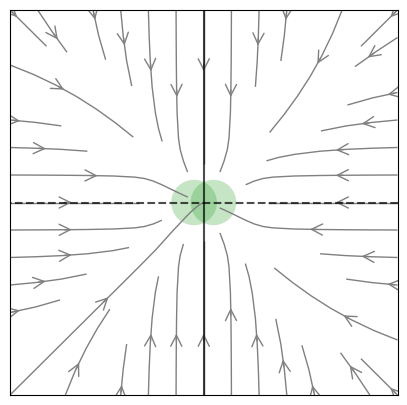

In [103]:
# Parameters of vizualisation 
L = 10.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(landscape, xx, yy, regime=0, color_scheme='fp_types')

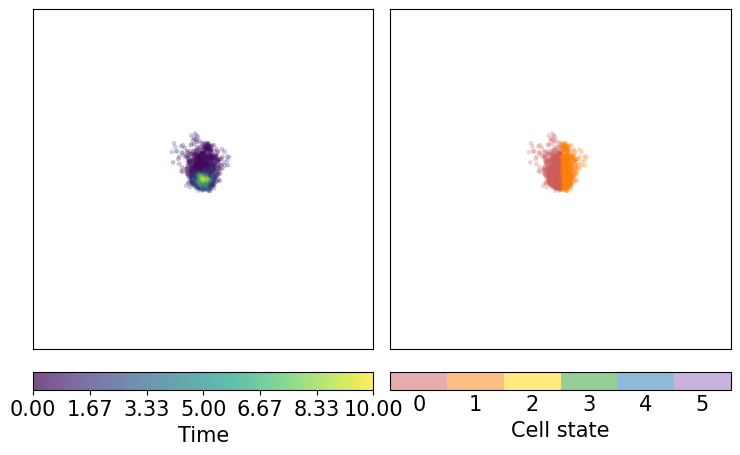

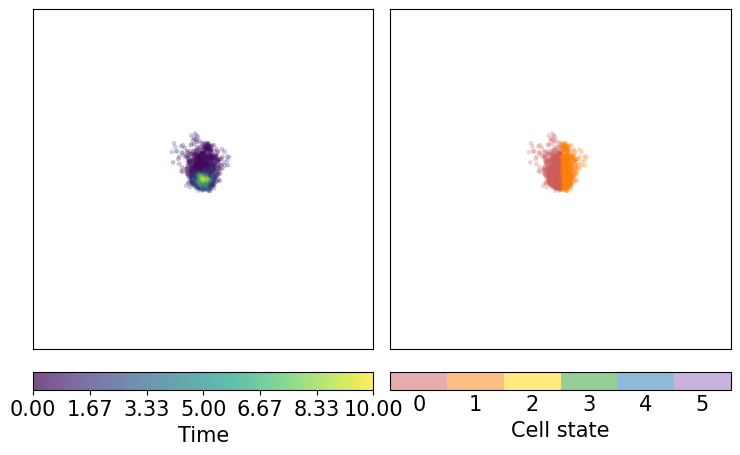

In [104]:
landscape.init_cells(n,landscape.init_cond,noise=init_noise)
get_and_plot_traj(landscape,t0,tf,nt,L,noise)

In [105]:
# n_frames = 100
# time_pars = (t0,tf, n_frames)
# print(landscape.n_regimes)
# labels = [f"regime {i}" for i in range(0,landscape.n_regimes+1)]
# print(labels)
# make_movie_discrete(landscape, xx, yy, labels, time_pars, n, noise, init_cond=landscape.init_cond,
#                         circles=True, circle_opacity=0.1, density=0.65, nullclines=False,
#                         fps=10, save_dir='../figures/', filename='start_traj.gif')

# save_dir = '../temp/figures/'
# import os, glob
# for f in glob.glob(save_dir + "frame_*.png"):
#     os.remove(f)

In [106]:
pytree = Experiment(landscape = landscape)

print(pytree.dynamic)
pytree.set_initial_conditions(q_init= q_init)
#We should depreciate set_regime as It shouldn't have to be set manually
pytree.set_regime_params(signal_param = signal_param)

pytree.set_simulation(n=n, init_noise=init_noise,t0=t0, tf=tf, nt= nt, ndt= ndt, noise=noise)

pytree.set_state_probs(get_cell_states=get_states)

# losses = pytree.optimize(user_fitness=fitness, fitness_params=loss_params, steps=steps, lr= lr)

losses = pytree.optimize(user_fitness=fitness, fitness_params=loss_params, steps=steps, optimizer=opt)

dynamic, static, traj, states = pytree.dynamic, pytree.static, pytree.trajectories, pytree.states

LandscapeDynamic(module=ModuleDynamic(x=Array([-0.5,  0.5], dtype=float32), y=Array([0., 0.], dtype=float32), a=Array([[1.5, 5. ],
       [1.5, 5. ]], dtype=float32), s=Array([[1., 1.],
       [1., 1.]], dtype=float32)))
Train step 0 : Loss = 0.5376087427139282
Train step 20 : Loss = 0.27392739057540894
Train step 40 : Loss = -0.30668899416923523
Train step 60 : Loss = -0.3031420111656189
Train step 80 : Loss = -0.30646151304244995
Train step 100 : Loss = -0.31389766931533813
Train step 120 : Loss = -0.31939494609832764
Train step 140 : Loss = -0.3274545967578888
Train step 160 : Loss = -0.37994807958602905
Train step 180 : Loss = -0.3910442590713501
Train step 200 : Loss = -0.456470787525177
Train step 220 : Loss = -0.43641889095306396
Train step 240 : Loss = -0.39230793714523315
Train step 260 : Loss = -0.41557419300079346
Train step 280 : Loss = -0.3924139142036438
Train step 300 : Loss = -0.43719446659088135
Train step 320 : Loss = -0.415592759847641
Train step 340 : Loss = -0.4937

In [107]:
print(dynamic)

LandscapeDynamic(module=ModuleDynamic(x=Array([-1.2951235,  1.2951902], dtype=float32), y=Array([ 0.85995394, -0.8576776 ], dtype=float32), a=Array([[1.8089738, 5.2736397],
       [1.1213889, 4.6606073]], dtype=float32), s=Array([[1.1602901, 1.       ],
       [1.108454 , 1.0010717]], dtype=float32)))


In [108]:
print(jnp.mean(states[:,-1]))

0.049999997


In [109]:
final_coord = traj[:,:,-1]

module_coord = jnp.stack((dynamic.module.x,dynamic.module.y))
m = module_coord.shape[1]
dist_squared = jnp.sum((final_coord.T[:, :, None] - module_coord)**2, axis=1)

weights = jnp.exp(-dist_squared / T)

P = weights / (jnp.sum(weights, axis=1, keepdims=True))

p_j = jnp.mean(P, axis=0)

loss_uniform = jnp.mean(kl_div(p_j,jnp.array(q_prob)))

uniform = jnp.ones_like(P) / P.shape[1]

loss_particle = -jnp.mean(
    jnp.sum(kl_div(P, uniform), axis=1)
)

print(P[:5,:], μ * loss_uniform, λ * loss_particle, losses[-1], jnp.mean(jnp.argmax(P,axis=1)))

[[9.9993712e-01 6.2860643e-05]
 [9.9950588e-01 4.9411139e-04]
 [9.9992871e-01 7.1269307e-05]
 [9.9999183e-01 8.1460294e-06]
 [9.9997902e-01 2.0991374e-05]] 0.23437113 -0.6918777 -0.41575408 0.049999997


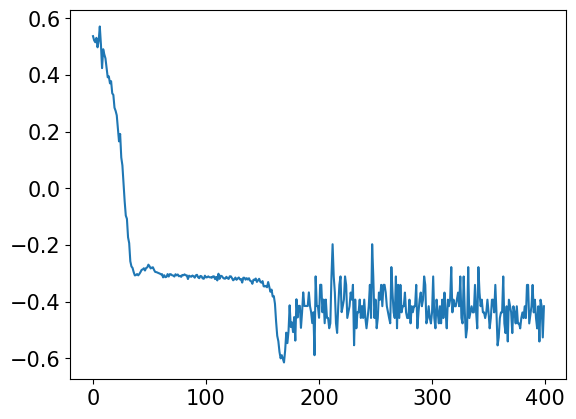

In [110]:
plt.plot(losses)

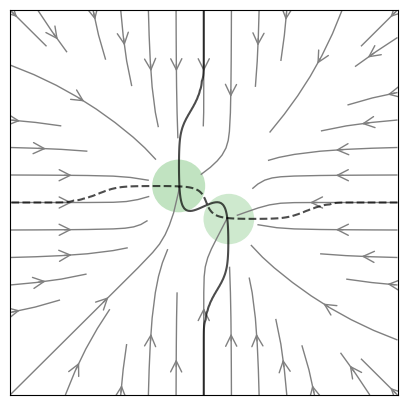

In [111]:
l = pytree.get_landscape()
fig = visualize_landscape(l, xx, yy, regime=0, color_scheme='fp_types')

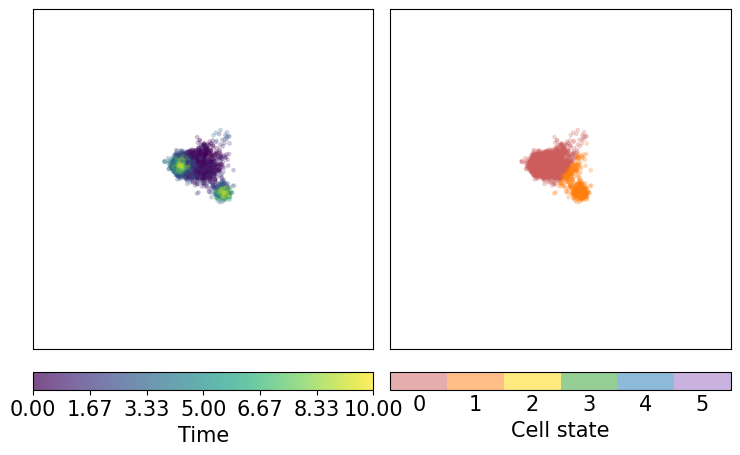

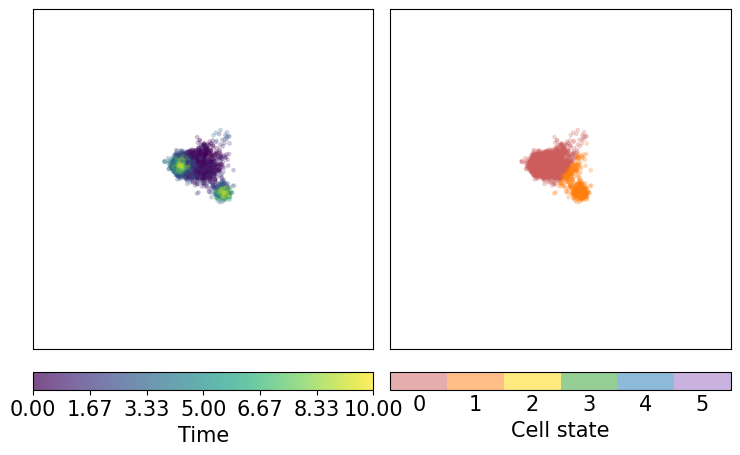

In [112]:
# Put back the coordinates of the cells at the init_ as the are
l.init_cells(n,static.init_cond,noise=init_noise)
get_and_plot_traj(l,t0,tf,nt,L,noise) 

In [113]:
n_frames = 100
time_pars = (t0,tf, n_frames)
labels = [f"regime {i}" for i in range(0,l.n_regimes)]
make_movie_discrete(l, xx, yy, labels, time_pars, n, noise, init_cond=l.init_cond,
                        circles=True, circle_opacity=0.1, density=0.65, nullclines=False,
                        fps=10, save_dir='../temp/figures/', filename='end_traj.gif')

save_dir = '../temp/figures/'
import os, glob
for f in glob.glob(save_dir + "frame_*.png"):
    os.remove(f)

Movie saved to ../temp/figures/end_traj.gif


In [114]:
n_frames = steps//10
make_movie_landscape(pytree.dynamic_vals,static, xx, yy, n_frames)